In [1]:
# ============================================
# УСТАНОВКА НЕОБХОДИМЫХ БИБЛИОТЕК
# ============================================

!pip install mne
!pip install pyEDFlib
!pip install numpy
!pip install scipy
!pip install pandas
!pip install matplotlib
!pip install antropy
!pip install scikit-learn
!pip install xgboost
!pip install openpyxl  # для работы с Excel файлами

# Если нужно сохранять графики
!pip install seaborn

In [2]:
# ============================================
# ИМПОРТЫ
# ============================================
import mne
import numpy as np
import pandas as pd
from scipy import signal
from scipy.stats import skew
from typing import Dict, List, Tuple, Optional
import os
from google.colab import drive

# Подключаем Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================

def load_psg_with_annotations(file_path: str):
    """Загрузка данных ПСГ с аннотациями"""
    try:
        print(f"📁 Загрузка: {os.path.basename(file_path)}")
        raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
        annotations = raw.annotations

        print(f"   ✅ Частота: {raw.info['sfreq']} Гц")
        print(f"   ✅ Каналы: {len(raw.ch_names)}")
        print(f"   ✅ Аннотаций: {len(annotations)}")

        return raw, annotations
    except Exception as e:
        print(f"   ❌ Ошибка: {e}")
        return None, None


# ============================================
# 2. ПРЕДОБРАБОТКА (ТОЛЬКО ЭЭГ)
# ============================================

def preprocess_eeg_only(raw: mne.io.Raw) -> mne.io.Raw:
    """
    Предобработка только ЭЭГ-каналов
    Фильтр: 0.5-45 Гц (включает гамму до 45 Гц) + режектор 50 Гц
    """
    raw_processed = raw.copy()

    # Только ЭЭГ-каналы
    eeg_channels = ['EEG F3-A2', 'EEG C3-A2', 'EEG O1-A2',
                    'EEG F4-A1', 'EEG C4-A1', 'EEG O2-A1']

    available_channels = [ch for ch in eeg_channels if ch in raw_processed.ch_names]

    if not available_channels:
        print("❌ ЭЭГ-каналы не найдены!")
        return None

    print(f"🧠 ЭЭГ-каналы: {available_channels}")

    for eeg_ch in available_channels:
        try:
            # Полосовой фильтр 0.5-45 Гц (включает гамму)
            raw_processed.filter(l_freq=0.5, h_freq=45,
                                picks=[eeg_ch], method='iir', verbose=False)
            # Режектор 50 Гц (подавление сетевой помехи)
            raw_processed.notch_filter(50, picks=[eeg_ch], verbose=False)
            print(f"   ✓ {eeg_ch}")
        except Exception as e:
            print(f"   ✗ Ошибка {eeg_ch}: {e}")

    return raw_processed


# ============================================
# 3. СОПОСТАВЛЕНИЕ АННОТАЦИЙ (разметка эксперта)
# ============================================

def map_annotation_to_epoch_fixed(epoch_start: float, epoch_end: float,
                                  annotations: mne.Annotations) -> Dict[str, any]:
    """Сопоставление аннотаций с эпохой (разметка эксперта)"""

    epoch_annotations = {
        'sleep_stage': -1,
        'apnea_count': 0,
        'hypopnea_count': 0,
        'snore_count': 0,
        'desaturation_count': 0,
        'tachycardia_count': 0,
        'leg_movement_count': 0,
        'periodic_leg_movement_count': 0,
        'bruxism_count': 0,
        'activation_count': 0,
        'k_complex_count': 0,
        'sleep_spindle_count': 0,
        'artefact_count': 0,
        'has_apnea': 0,
        'has_hypopnea': 0,
        'has_desaturation': 0,
        'has_snore': 0,
        'has_bruxism': 0,
    }

    sleep_stage_map = {
        'Sleep stage W': 0, 'Sleep stage W(eventUnknown)': 0,
        'Sleep stage 1': 1, 'Sleep stage 1(eventUnknown)': 1,
        'Sleep stage 2': 2, 'Sleep stage 2(eventUnknown)': 2,
        'Sleep stage 3': 3, 'Sleep stage 3(eventUnknown)': 3,
        'Sleep stage R': 4, 'Sleep stage R(eventUnknown)': 4,
        'pointPolySomnographyREM': 4, 'БДГ': 4
    }

    event_type_map = {
        'pointPolySomnographyObstructiveApnea': 'apnea',
        'Obstructive апноэ': 'apnea',
        'pointPolySomnographyHypopnea': 'hypopnea',
        'pointPolySomnographySnore': 'snore',
        'pointPolySomnographyTachycardia': 'tachycardia',
        'pointPolySomnographyDesaturation': 'desaturation',
        'pointPolySomnographyLegsMovements': 'leg_movement',
        'pointPolySomnographyPeriodicalLegsMovements': 'periodic_leg_movement',
        'pointBruxism': 'bruxism',
        'Бруксизм': 'bruxism',
        'pointPolySomnographyActivation': 'activation',
        'pointPolySomnographyK_complex': 'k_complex',
        'pointPolySomnographySleepSpindle': 'sleep_spindle',
        'blockArtefact': 'artefact'
    }

    for ann_start, ann_duration, ann_description in zip(
        annotations.onset, annotations.duration, annotations.description):

        ann_end = ann_start + ann_duration

        if not (ann_end < epoch_start or ann_start > epoch_end):
            overlap_duration = min(ann_end, epoch_end) - max(ann_start, epoch_start)

            if overlap_duration > 0:
                desc = str(ann_description)
                desc_lower = desc.lower()
                matched = False

                # Стадии сна
                if 'бдг' in desc_lower or 'pointpolysomnographyrem' in desc_lower:
                    epoch_annotations['sleep_stage'] = 4
                    matched = True
                elif 'sleep stage' in desc_lower:
                    for stage_key, stage_code in sleep_stage_map.items():
                        if stage_key.lower() in desc_lower:
                            epoch_annotations['sleep_stage'] = stage_code
                            matched = True
                            break

                # События (апноэ, гипопноэ и др.)
                if not matched:
                    for event_key, event_type in event_type_map.items():
                        event_found = False

                        if event_key.lower() in desc_lower:
                            event_found = True
                        elif event_type == 'apnea' and any(word in desc_lower for word in ['апноэ', 'apnea']):
                            event_found = True
                        elif event_type == 'bruxism' and any(word in desc_lower for word in ['бруксизм', 'bruxism']):
                            event_found = True
                        elif event_type == 'hypopnea' and any(word in desc_lower for word in ['гипопноэ', 'hypopnea']):
                            event_found = True

                        if event_found:
                            count_key = f'{event_type}_count'
                            if count_key in epoch_annotations:
                                epoch_annotations[count_key] += 1

                            binary_key = f'has_{event_type}'
                            if binary_key in epoch_annotations:
                                epoch_annotations[binary_key] = 1

                            matched = True
                            break

    return epoch_annotations


# ============================================
# 4. ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ЭЭГ
# ============================================

def extract_eeg_features_for_apnea(epoch_data: np.ndarray, fs: int,
                                    channel_name: str, prefix: str) -> Dict[str, float]:
    """
    Извлечение признаков ЭЭГ для диагностики апноэ
    Включает: статистические, спектральные (дельта, тета, альфа, бета, ГАММА),
              энтропийные, динамические
    """
    features = {}

    if 'EEG' not in channel_name:
        return features

    try:
        # ========== 1. СПЕКТРАЛЬНЫЕ ПРИЗНАКИ ==========
        freqs, psd = signal.welch(epoch_data, fs, nperseg=min(128, len(epoch_data)))

        # Частотные диапазоны
        bands = {
            'delta': (0.5, 4),      # глубокий сон
            'theta': (4, 8),        # дремотное состояние
            'alpha': (8, 13),       # расслабленное бодрствование
            'beta': (13, 30),       # активное бодрствование
            'gamma': (30, 45)       # НОВЫЙ ДИАПАЗОН!
        }

        total_power = 0
        band_powers = {}

        for band_name, (low, high) in bands.items():
            band_mask = (freqs >= low) & (freqs <= high)
            if np.any(band_mask):
                power = np.sum(psd[band_mask])
                band_powers[band_name] = power
                features[f'{prefix}{band_name}_power'] = float(power)
                total_power += power

        # Относительная мощность
        if total_power > 0:
            for band_name in bands.keys():
                rel_power = band_powers[band_name] / total_power
                features[f'{prefix}{band_name}_ratio'] = float(rel_power)

        # Соотношение медленных/быстрых ритмов (индикатор замедления мозга)
        if band_powers.get('delta', 0) + band_powers.get('theta', 0) > 0:
            slow_fast = (band_powers.get('delta', 0) + band_powers.get('theta', 0)) / \
                        (band_powers.get('alpha', 0) + band_powers.get('beta', 0) + 1e-10)
            features[f'{prefix}slow_fast_ratio'] = float(slow_fast)

        # ========== 2. ЭНТРОПИЯ ШЕННОНА (мера хаоса) ==========
        data_norm = epoch_data - np.min(epoch_data)
        if np.sum(data_norm) > 0:
            data_prob = data_norm / np.sum(data_norm)
            shannon_entropy = -np.sum(data_prob * np.log2(data_prob + 1e-10))
            features[f'{prefix}shannon_entropy'] = float(shannon_entropy)

        # ========== 3. СТАТИСТИЧЕСКИЕ ПРИЗНАКИ ==========
        mean_val = np.mean(epoch_data)
        std_val = np.std(epoch_data)

        features[f'{prefix}mean'] = float(mean_val)
        features[f'{prefix}std'] = float(std_val)
        features[f'{prefix}min'] = float(np.min(epoch_data))
        features[f'{prefix}max'] = float(np.max(epoch_data))
        features[f'{prefix}range'] = float(np.ptp(epoch_data))
        features[f'{prefix}rms'] = float(np.sqrt(np.mean(epoch_data**2)))

        if mean_val != 0:
            features[f'{prefix}cv'] = float(std_val / abs(mean_val))

        features[f'{prefix}skewness'] = float(skew(epoch_data))

        # ========== 4. ДИНАМИЧЕСКИЕ ПРИЗНАКИ ==========
        zc = np.sum(np.abs(np.diff(np.sign(epoch_data))) > 0)
        features[f'{prefix}zc_rate'] = float(zc / len(epoch_data))

        diff1 = np.diff(epoch_data)
        var_x = np.var(epoch_data)
        var_dx = np.var(diff1) if len(diff1) > 0 else 0
        if var_x > 0:
            features[f'{prefix}mobility'] = float(np.sqrt(var_dx / var_x))

    except Exception as e:
        pass

    return features


# ============================================
# 5. ИЗВЛЕЧЕНИЕ ЭПОХ (только ЭЭГ)
# ============================================

def extract_epochs_eeg_only(raw: mne.io.Raw, annotations: mne.Annotations,
                            epoch_duration: int = 30):
    """
    Извлечение эпох только для ЭЭГ-каналов
    """
    data, times = raw[:, :]
    total_samples = data.shape[1]
    fs = int(raw.info['sfreq'])
    epoch_samples = int(epoch_duration * fs)

    # Только ЭЭГ-каналы
    eeg_channels = ['EEG F3-A2', 'EEG C3-A2', 'EEG O1-A2',
                    'EEG F4-A1', 'EEG C4-A1', 'EEG O2-A1']

    epochs_dict = {}
    annotations_list = []

    print(f"📊 Извлечение эпох ({epoch_duration} сек)...")

    for ch_name in raw.ch_names:
        if ch_name not in eeg_channels:
            continue

        ch_idx = raw.ch_names.index(ch_name)
        channel_data = data[ch_idx]
        epochs = []

        start_sample = 0
        epoch_idx = 0

        while start_sample + epoch_samples <= total_samples:
            end_sample = start_sample + epoch_samples
            epoch_start_time = start_sample / fs
            epoch_end_time = end_sample / fs

            epoch = channel_data[start_sample:end_sample]
            epochs.append(epoch)

            # Аннотации только для первого ЭЭГ-канала
            if ch_name == eeg_channels[0]:
                epoch_anns = map_annotation_to_epoch_fixed(
                    epoch_start_time, epoch_end_time, annotations
                )
                epoch_anns['epoch_idx'] = epoch_idx
                epoch_anns['start_time'] = epoch_start_time
                epoch_anns['end_time'] = epoch_end_time
                annotations_list.append(epoch_anns)

            start_sample += epoch_samples
            epoch_idx += 1

        epochs_dict[ch_name] = np.array(epochs)

    print(f"   ✅ Эпох: {len(annotations_list)}")
    print(f"   ✅ ЭЭГ-каналов: {list(epochs_dict.keys())}")

    return epochs_dict, annotations_list


# ============================================
# 6. ОСНОВНАЯ ФУНКЦИЯ ОБРАБОТКИ ПАЦИЕНТА
# ============================================

def process_patient_eeg(patient_file: str, patient_id: int) -> pd.DataFrame:
    """
    Обработка одного пациента: загрузка, фильтрация, извлечение признаков
    Выход: датафрейм с ЭЭГ-признаками и разметкой по эпохам
    """
    print(f"\n{'='*60}")
    print(f"👤 ПАЦИЕНТ {patient_id}")
    print(f"📁 {os.path.basename(patient_file)}")
    print(f"{'='*60}")

    # 1. Загрузка
    raw, annotations = load_psg_with_annotations(patient_file)
    if raw is None:
        return None

    # 2. Предобработка только ЭЭГ
    raw_processed = preprocess_eeg_only(raw)
    if raw_processed is None:
        return None

    # 3. Извлечение эпох
    epochs_dict, annotations_list = extract_epochs_eeg_only(raw_processed, annotations)

    # 4. Извлечение признаков
    features_list = []
    total_epochs = len(epochs_dict[list(epochs_dict.keys())[0]])

    print(f"📊 Извлечение признаков для {total_epochs} эпох...")

    fs = int(raw_processed.info['sfreq'])

    for epoch_idx in range(total_epochs):
        epoch_features = {}

        for ch_name, epochs in epochs_dict.items():
            epoch_data = epochs[epoch_idx]
            prefix = f"{ch_name}_"

            eeg_features = extract_eeg_features_for_apnea(
                epoch_data, fs, ch_name, prefix
            )
            epoch_features.update(eeg_features)

        # Добавляем аннотации
        if epoch_idx < len(annotations_list):
            epoch_features.update(annotations_list[epoch_idx])

        epoch_features['patient_id'] = patient_id
        features_list.append(epoch_features)

    df = pd.DataFrame(features_list)
    print(f"✅ Готово! Размер: {df.shape}")

    return df


# ============================================
# 7. ЗАПУСК ОБРАБОТКИ ВСЕХ ФАЙЛОВ
# ============================================

def process_all_patients(folder_path: str) -> pd.DataFrame:
    """
    Обработка всех EDF файлов в папке
    """
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.edf')]

    print(f"\n🔍 Найдено EDF файлов: {len(all_files)}")

    all_data = []

    for i, file_name in enumerate(all_files, 1):
        file_path = os.path.join(folder_path, file_name)
        df_patient = process_patient_eeg(file_path, i)

        if df_patient is not None and not df_patient.empty:
            all_data.append(df_patient)

    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        print(f"\n{'='*60}")
        print(f"🎉 ИТОГО: {len(final_df)} эпох, {len(final_df.columns)} признаков")
        print(f"{'='*60}")
        return final_df
    else:
        print("❌ Нет данных для обработки")
        return pd.DataFrame()


# ============================================
# 8. ЗАПУСК
# ============================================

# Путь к папке с EDF файлами
folder_path = "/content/drive/MyDrive/Disertacia/EDF"

# Запускаем обработку
df_result = process_all_patients(folder_path)

# Сохраняем результат
if not df_result.empty:
    df_result.to_csv('/content/drive/MyDrive/Disertacia/eeg_dataset.csv', index=False)
    print("\n✅ Датасет сохранен: eeg_dataset.csv")

    # Показываем первые колонки
    print("\n📋 Первые 10 колонок датасета:")
    eeg_cols = [c for c in df_result.columns if 'EEG' in c]
    for col in eeg_cols[:10]:
        print(f"   {col}")


🔍 Найдено EDF файлов: 5

👤 ПАЦИЕНТ 1
📁 812773.edf
📁 Загрузка: 812773.edf
   ✅ Частота: 250.0 Гц
   ✅ Каналы: 20
   ✅ Аннотаций: 11994
🧠 ЭЭГ-каналы: ['EEG F3-A2', 'EEG C3-A2', 'EEG O1-A2', 'EEG F4-A1', 'EEG C4-A1', 'EEG O2-A1']
   ✓ EEG F3-A2
   ✓ EEG C3-A2
   ✓ EEG O1-A2
   ✓ EEG F4-A1
   ✓ EEG C4-A1
   ✓ EEG O2-A1
📊 Извлечение эпох (30 сек)...
   ✅ Эпох: 910
   ✅ ЭЭГ-каналов: ['EEG F3-A2', 'EEG C3-A2', 'EEG O1-A2', 'EEG F4-A1', 'EEG C4-A1', 'EEG O2-A1']
📊 Извлечение признаков для 910 эпох...
✅ Готово! Размер: (910, 154)

👤 ПАЦИЕНТ 2
📁 072924.edf
📁 Загрузка: 072924.edf
   ✅ Частота: 250.0 Гц
   ✅ Каналы: 20
   ✅ Аннотаций: 14029
🧠 ЭЭГ-каналы: ['EEG F3-A2', 'EEG C3-A2', 'EEG O1-A2', 'EEG F4-A1', 'EEG C4-A1', 'EEG O2-A1']
   ✓ EEG F3-A2
   ✓ EEG C3-A2
   ✓ EEG O1-A2
   ✓ EEG F4-A1
   ✓ EEG C4-A1
   ✓ EEG O2-A1
📊 Извлечение эпох (30 сек)...
   ✅ Эпох: 1007
   ✅ ЭЭГ-каналов: ['EEG F3-A2', 'EEG C3-A2', 'EEG O1-A2', 'EEG F4-A1', 'EEG C4-A1', 'EEG O2-A1']
📊 Извлечение признаков для 1007 эпох

/tmp/ipykernel_33829/3660012997.py:9: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


   ✅ Частота: 250.0 Гц
   ✅ Каналы: 20
   ✅ Аннотаций: 14181
🧠 ЭЭГ-каналы: ['EEG F3-A2', 'EEG C3-A2', 'EEG O1-A2', 'EEG F4-A1', 'EEG C4-A1', 'EEG O2-A1']
   ✓ EEG F3-A2
   ✓ EEG C3-A2
   ✓ EEG O1-A2
   ✓ EEG F4-A1
   ✓ EEG C4-A1
   ✓ EEG O2-A1
📊 Извлечение эпох (30 сек)...
   ✅ Эпох: 910
   ✅ ЭЭГ-каналов: ['EEG F3-A2', 'EEG C3-A2', 'EEG O1-A2', 'EEG F4-A1', 'EEG C4-A1', 'EEG O2-A1']
📊 Извлечение признаков для 910 эпох...
✅ Готово! Размер: (910, 154)

🎉 ИТОГО: 4638 эпох, 154 признаков

✅ Датасет сохранен: eeg_dataset.csv

📋 Первые 10 колонок датасета:
   EEG F3-A2_delta_power
   EEG F3-A2_theta_power
   EEG F3-A2_alpha_power
   EEG F3-A2_beta_power
   EEG F3-A2_gamma_power
   EEG F3-A2_delta_ratio
   EEG F3-A2_theta_ratio
   EEG F3-A2_alpha_ratio
   EEG F3-A2_beta_ratio
   EEG F3-A2_gamma_ratio


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Увеличим размер шрифта для графиков
plt.rcParams.update({'font.size': 10})

# ---------- 1. Загрузка файла (пример) ----------
file_path = "/content/drive/MyDrive/Disertacia/EDF/812773.edf"
raw, annotations = load_psg_with_annotations(file_path)
raw_processed = preprocess_eeg_only(raw)
print(raw.ch_names)

📁 Загрузка: 812773.edf
   ✅ Частота: 250.0 Гц
   ✅ Каналы: 20
   ✅ Аннотаций: 11994
🧠 ЭЭГ-каналы: ['EEG F3-A2', 'EEG C3-A2', 'EEG O1-A2', 'EEG F4-A1', 'EEG C4-A1', 'EEG O2-A1']
   ✓ EEG F3-A2
   ✓ EEG C3-A2
   ✓ EEG O1-A2
   ✓ EEG F4-A1
   ✓ EEG C4-A1
   ✓ EEG O2-A1
['EEG F3-A2', 'EEG C3-A2', 'EEG O1-A2', 'EEG F4-A1', 'EEG C4-A1', 'EEG O2-A1', 'EMG P3-P4_AMG[SH', 'EOG EOGl FP1-A2_', 'EOG EOGr FP2-A1_', 'EMG LMl T3-T5_Le', 'EMG LMr T4-T6_Pr', 'SOUND Snore', 'ECG  ECG', 'RESP CHEST Thora', 'RESP ABDOMEN Abd', 'POSITION Polojen', 'RESP Breath', 'SAO2 SpO2', 'PPG', 'EEG CZ_CZ-A1']


Апноэ: 3002.1–3065.5 с
Окно: 2997.1–3007.1 с


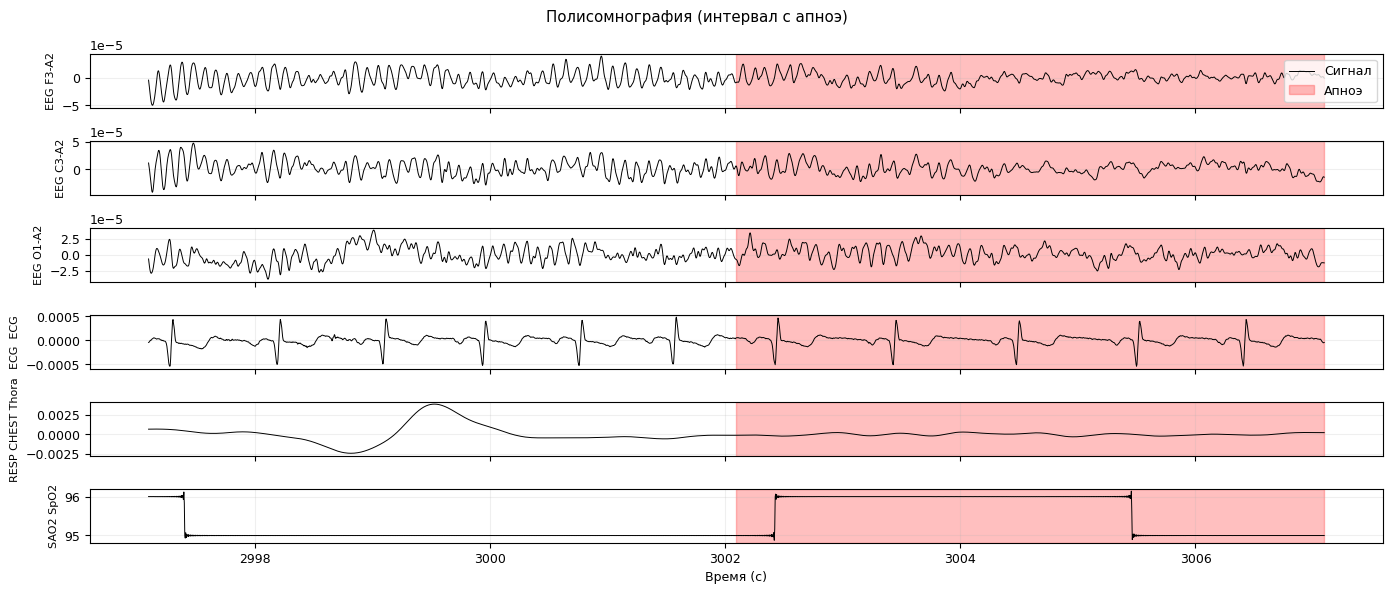

Сохранён psg_final.png


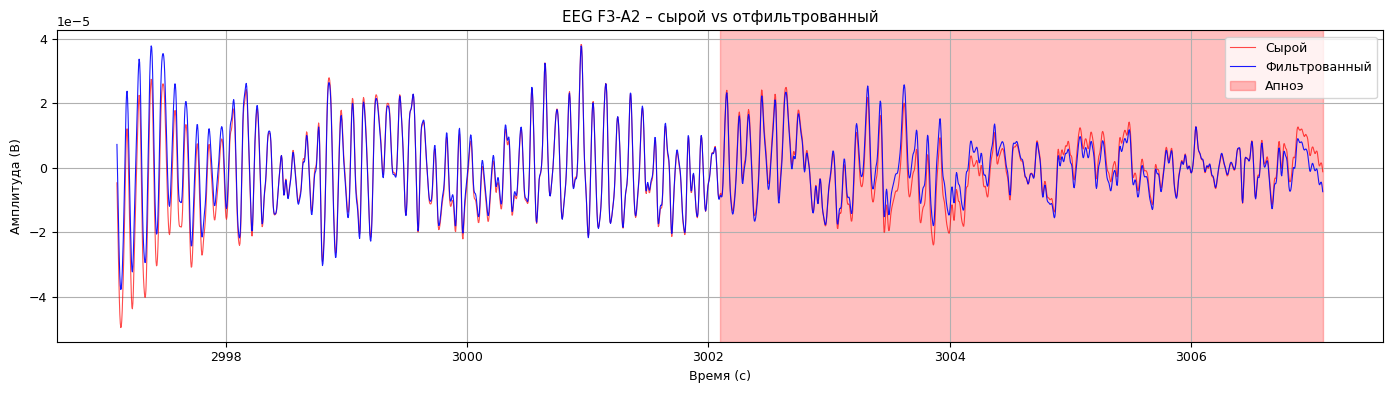

Сохранён compare_final.png


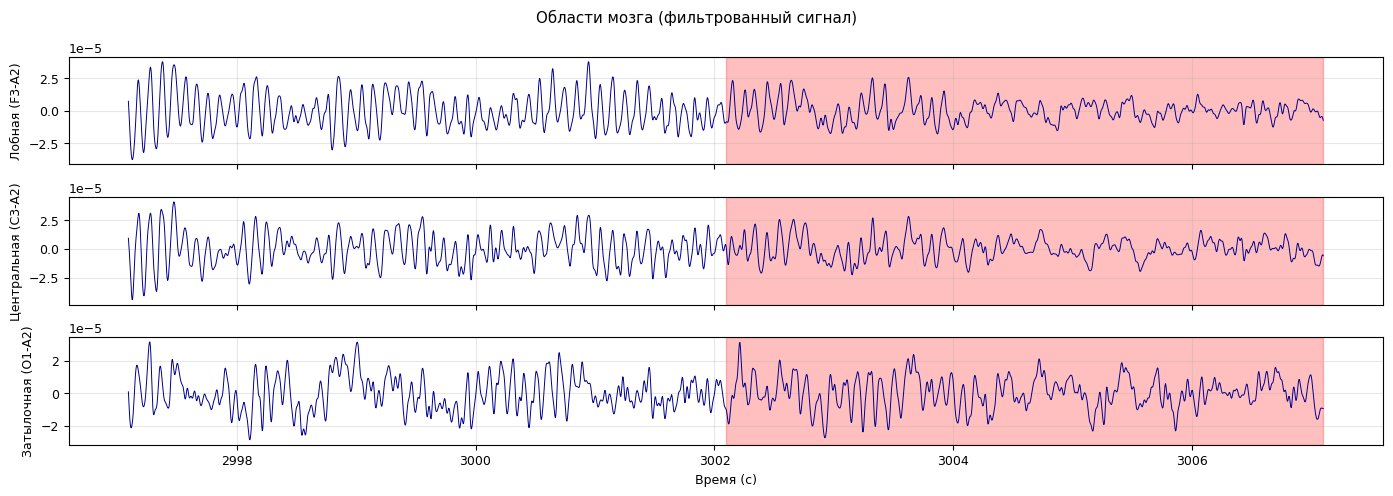

Сохранён regions_final.png


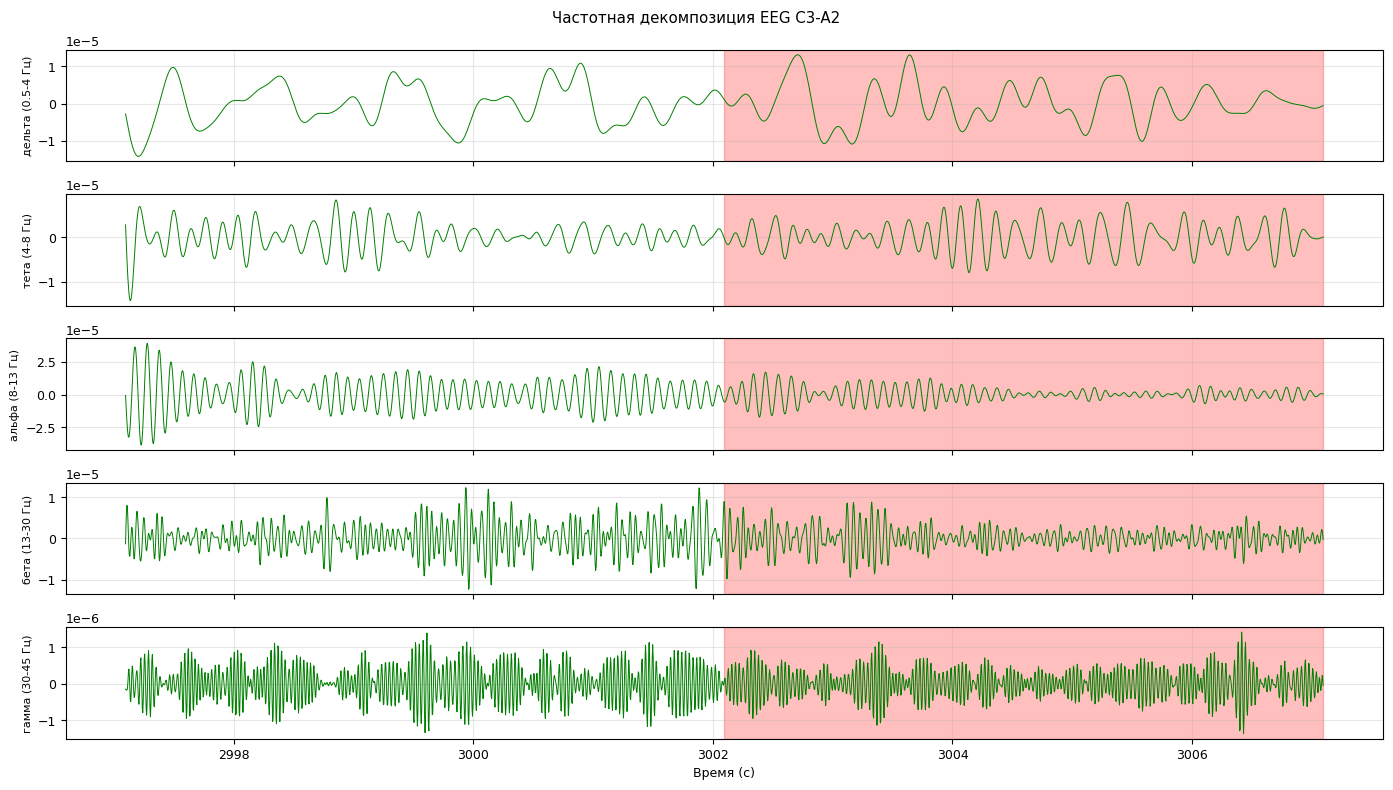

Сохранён decomp_final.png


In [16]:
# ============================================
# ГАРАНТИРОВАННОЕ ПОСТРОЕНИЕ ГРАФИКОВ С СИГНАЛОМ
# ============================================
import matplotlib.pyplot as plt
import numpy as np

# Находим первое апноэ (уже сделано, но для надёжности повторим)
apnea_start = None
apnea_end = None
for onset, dur, desc in zip(annotations.onset, annotations.duration, annotations.description):
    if 'apnea' in desc.lower():
        apnea_start = onset
        apnea_end = onset + dur
        break

if apnea_start is None:
    print("Апноэ не найдено.")
else:
    # Окно: 5 секунд до и 5 секунд после начала апноэ (всего 10 секунд)
    win_start = max(0, apnea_start - 5)
    win_end = apnea_start + 5
    print(f"Апноэ: {apnea_start:.1f}–{apnea_end:.1f} с")
    print(f"Окно: {win_start:.1f}–{win_end:.1f} с")

    # Частота дискретизации
    fs = raw.info['sfreq']
    idx_start = int(win_start * fs)
    idx_end = int(win_end * fs)
    # Временная ось
    t = np.linspace(win_start, win_end, idx_end - idx_start)

    # ------ 1. Полисомнография (основные каналы) ------
    psg_channels = ['EEG F3-A2', 'EEG C3-A2', 'EEG O1-A2',
                    'ECG  ECG', 'RESP CHEST Thora', 'SAO2 SpO2']
    available = [ch for ch in psg_channels if ch in raw.ch_names]
    fig, axes = plt.subplots(len(available), 1, figsize=(14, 1.0*len(available)), sharex=True)
    if len(available) == 1:
        axes = [axes]
    for i, ch in enumerate(available):
        ch_idx = raw.ch_names.index(ch)
        data = raw.get_data(picks=[ch_idx], start=idx_start, stop=idx_end)[0]
        axes[i].plot(t, data, color='k', linewidth=0.7)
        axes[i].set_ylabel(ch, fontsize=8)
        axes[i].grid(True, alpha=0.2)
        axes[i].axvspan(apnea_start, min(apnea_end, win_end), alpha=0.25, color='red')
        if i == 0:
            axes[i].legend(['Сигнал', 'Апноэ'], loc='upper right')
    axes[-1].set_xlabel('Время (с)')
    fig.suptitle('Полисомнография (интервал с апноэ)')
    plt.tight_layout()
    plt.savefig('psg_final.png', dpi=150)
    plt.show()
    print("Сохранён psg_final.png")

    # ------ 2. Сравнение сырого и отфильтрованного для F3-A2 ------
    ch = 'EEG F3-A2'
    if ch in raw.ch_names and ch in raw_processed.ch_names:
        idx_ch = raw.ch_names.index(ch)
        data_raw = raw.get_data(picks=[idx_ch], start=idx_start, stop=idx_end)[0]
        idx_ch_proc = raw_processed.ch_names.index(ch)
        data_filt = raw_processed.get_data(picks=[idx_ch_proc], start=idx_start, stop=idx_end)[0]
        plt.figure(figsize=(14, 4))
        plt.plot(t, data_raw, 'r-', alpha=0.7, label='Сырой', linewidth=0.8)
        plt.plot(t, data_filt, 'b-', alpha=0.9, label='Фильтрованный', linewidth=0.8)
        plt.axvspan(apnea_start, min(apnea_end, win_end), alpha=0.25, color='red', label='Апноэ')
        plt.xlabel('Время (с)')
        plt.ylabel('Амплитуда (В)')
        plt.title(f'{ch} – сырой vs отфильтрованный')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig('compare_final.png', dpi=150)
        plt.show()
        print("Сохранён compare_final.png")

    # ------ 3. Области мозга (фильтрованный сигнал) ------
    regions = {
        'Лобная (F3-A2)': 'EEG F3-A2',
        'Центральная (C3-A2)': 'EEG C3-A2',
        'Затылочная (O1-A2)': 'EEG O1-A2'
    }
    fig, axes = plt.subplots(3, 1, figsize=(14, 5), sharex=True)
    for ax, (name, ch_name) in zip(axes, regions.items()):
        if ch_name in raw_processed.ch_names:
            idx_ch = raw_processed.ch_names.index(ch_name)
            data = raw_processed.get_data(picks=[idx_ch], start=idx_start, stop=idx_end)[0]
            ax.plot(t, data, color='darkblue', linewidth=0.7)
            ax.set_ylabel(name, fontsize=9)
            ax.grid(True, alpha=0.3)
            ax.axvspan(apnea_start, min(apnea_end, win_end), alpha=0.25, color='red')
    axes[-1].set_xlabel('Время (с)')
    fig.suptitle('Области мозга (фильтрованный сигнал)')
    plt.tight_layout()
    plt.savefig('regions_final.png', dpi=150)
    plt.show()
    print("Сохранён regions_final.png")

    # ------ 4. Частотная декомпозиция (фильтр для C3-A2) ------
    ch_dec = 'EEG C3-A2'
    if ch_dec in raw_processed.ch_names:
        from scipy.signal import butter, filtfilt
        idx_ch = raw_processed.ch_names.index(ch_dec)
        original = raw_processed.get_data(picks=[idx_ch], start=idx_start, stop=idx_end)[0]
        bands = {
            'дельта (0.5-4 Гц)': (0.5, 4),
            'тета (4-8 Гц)': (4, 8),
            'альфа (8-13 Гц)': (8, 13),
            'бета (13-30 Гц)': (13, 30),
            'гамма (30-45 Гц)': (30, 45)
        }
        fig, axes = plt.subplots(len(bands), 1, figsize=(14, 8), sharex=True)
        for ax, (name, (low, high)) in zip(axes, bands.items()):
            b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
            filtered = filtfilt(b, a, original)
            ax.plot(t, filtered, color='green', linewidth=0.7)
            ax.set_ylabel(name, fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.axvspan(apnea_start, min(apnea_end, win_end), alpha=0.25, color='red')
        axes[-1].set_xlabel('Время (с)')
        fig.suptitle(f'Частотная декомпозиция {ch_dec}')
        plt.tight_layout()
        plt.savefig('decomp_final.png', dpi=150)
        plt.show()
        print("Сохранён decomp_final.png")